<a href="https://colab.research.google.com/github/07-khanh/Hands-On-ML/blob/main/10_building_nn_with_pyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
from sklearn.model_selection import train_test_split
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [4]:
import torch
X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_val = torch.FloatTensor(y_val).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

---

We load batches of data using `DataLoader`, which creates nonoverlapping batches from a dataset. Before using DataLoader, we have to wrap the training data into a `Dataset` (linking each instance in `X_train` with the corresponding label in `y_train`), and we achieve this using `TensorDataset`

---


In [5]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)

In [6]:
n_features = X_train.shape[1]

In [7]:
device = 'cpu'

if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'

In [8]:
import torch.nn as nn

torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
)
model.to(device)

learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

---

If you are using a CUDA device, you should generally set `pin_memory=True` when creating the data loader: this will allocate the data in page-locked memory which guarantees a fixed physical memory location in the CPU RAM, and therefore allows direct memory access (DMA) transfers to the GPU, eliminating an
extra copy operation that would otherwise be needed. While this could use more CPU RAM since the memory cannot be swapped out to disk, it typically
results in significantly faster data transfers and thus faster training.

When transferring a tensor to the GPU using its `to()` method, you may also set `non_blocking=True` to avoid blocking the CPU during the data transfer (this only works if `pin_memory=True`).

---

In [9]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device, non_blocking=True) #
      y_batch = y_batch.to(device, non_blocking=True)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {mean_loss:.4f}")

In [10]:
n_epochs = 20
train(model, optimizer, mse, train_loader, n_epochs)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20, Loss: 0.5900
Epoch 2/20, Loss: 0.4046
Epoch 3/20, Loss: 0.3797
Epoch 4/20, Loss: 0.3628
Epoch 5/20, Loss: 0.3529
Epoch 6/20, Loss: 0.3523
Epoch 7/20, Loss: 0.3412
Epoch 8/20, Loss: 0.3409
Epoch 9/20, Loss: 0.3399
Epoch 10/20, Loss: 0.3446
Epoch 11/20, Loss: 0.3312
Epoch 12/20, Loss: 0.3262
Epoch 13/20, Loss: 0.3240
Epoch 14/20, Loss: 0.3209
Epoch 15/20, Loss: 0.3191
Epoch 16/20, Loss: 0.3152
Epoch 17/20, Loss: 0.3126
Epoch 18/20, Loss: 0.3102
Epoch 19/20, Loss: 0.3087
Epoch 20/20, Loss: 0.3063


---

**Note**: some others optimization you can apply to `DataLoader`:
- `num_workers`: The current training loop waits until a batch has been fully processed before it loads the next batch. You can often speed up training by pre-fetching the next batches on the CPU while the GPU is still working on the current batch. Forthis, set the data loader’s `num_workers` argument to the number of processes you want to use for data loading and preprocessing.
- `prefetch_factor`: Number of batches loaded in advance by each worker
- `persistent_workers=True`: the workers can be destroyed and created again between epochs, which creates overhead. Setting `persistent_workers` to True can keep them alive across many epochs.

---

# Model Evaluation

In [11]:
def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
  model.eval()
  metrics = []
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device) #
        y_batch = y_batch.to(device)
        y_pred = model(X_batch)
        metric = metric_fn(y_pred, y_batch)
        metrics.append(metric) # list of tensors, each tensor having one number
  return aggregate_fn(torch.stack(metrics)) # torch.stack concatenates a sequence of tensors along a new dimension

In [12]:
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32)
val_mse = evaluate(model, val_loader, mse)
val_mse

tensor(0.2948)

---

However, sometimes it is difficult to aggregate results across batches correctly (as if calculated on the entire data). In these cases, you may prefer using `TorchMetrics` library.

Instead of manually calculating a metric for every batch and figuring out how to combine the results, `TorchMetrics` keeps track of the necessary statistics across batches and computes the final metric correctly. Another benefit is that it works nicely with GPU too as it can live on CUDA.

---

In [13]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.3 MB/s eta 0:00:00


In [14]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset() # clear the accumulated state
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(X_batch)
        metric.update(y_pred, y_batch) # accumulate information from this batch
  return metric.compute() # calculate the final metric from everything accumulated

In [15]:
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model, val_loader, rmse)

tensor(0.5430)

In [16]:
def train2(model, optimizer, metric, criterion, train_loader, val_loader, n_epochs):
  model.train()
  metric_history = {'train_metrics': [], 'val_metrics': []}
  for epoch in range(n_epochs):
    metric.reset()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss
      metric.update(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    train_loss = total_loss / len(train_loader)
    train_metric = metric.compute().item()
    val_metric = evaluate_tm(model, val_loader, metric).item()
    metric_history['train_metrics'].append(train_metric)
    metric_history['val_metrics'].append(val_metric)
    print(f'Epoch {epoch+1}/{n_epochs}, train loss: {train_loss:.4f}, train metric: {train_metric:.4f}, val metric: {val_metric:.4f}')
  return metric_history

In [17]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model.to(device)

learning_rate = 0.01
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train2(model, optimizer, rmse, mse, train_loader, val_loader, n_epochs)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20, train loss: 0.7826, train metric: 0.8847, val metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, val metric: 0.6099
Epoch 3/20, train loss: 0.3929, train metric: 0.6269, val metric: 0.6146
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, val metric: 0.5964
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, val metric: 0.5912
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, val metric: 0.5965
Epoch 7/20, train loss: 0.3534, train metric: 0.5944, val metric: 0.6094
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, val metric: 0.6019
Epoch 9/20, train loss: 0.3455, train metric: 0.5878, val metric: 0.5742
Epoch 10/20, train loss: 0.3418, train metric: 0.5847, val metric: 0.6028
Epoch 11/20, train loss: 0.3401, train metric: 0.5831, val metric: 0.5884
Epoch 12/20, train loss: 0.3364, train metric: 0.5801, val metric: 0.5742
Epoch 13/20, train loss: 0.3353, train metric: 0.5789, val metric: 0.5855
Epoch 14/20, train loss: 0.3311, train metric: 

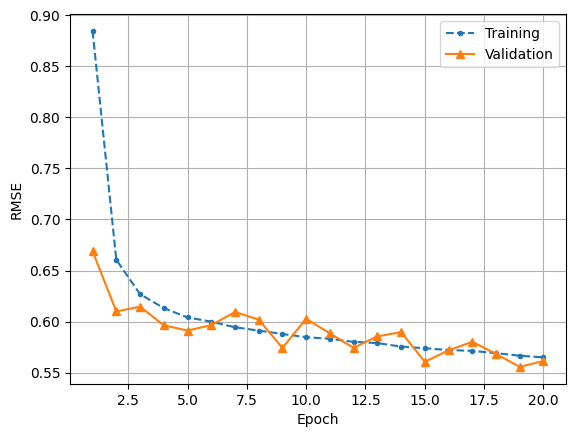

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(n_epochs)+1, history['train_metrics'], '.--', label='Training')
plt.plot(np.arange(n_epochs)+1, history['val_metrics'], '^-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
plt.show()

# Building Nonsequential Models Using Custom Modules

One example of a nonsequential neural network is a Wide & Deep neural network.

A Wide & Deep neural network is an architecture that combines two different ways of learning:
- Wide → memorize specific patterns and useful feature combinations (short path).
- Deep → generalize through learned representations and nonlinear interactions (deep path).
<img src='https://1.bp.blogspot.com/-Dw1mB9am1l8/V3MgtOzp3uI/AAAAAAAABGs/mP-3nZQCjWwdk6qCa5WraSpK8A7rSPj3ACLcB/s1600/image04.png'>

The short path can also be used to provide manually engineered features to the neural network. In contrast, a regular MLP forces all the data to flow through the full stack of layers; thus, simple patterns in the data may end up being distorted by this sequence of transformations.

In [19]:
class WideAndDeep(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU()
    )
    self.output_layer = nn.Linear(40 + n_features, 1)

  def forward(self, X):
    deep_output = self.deep_stack(X)
    wide_and_deep = torch.concat([X, deep_output], dim=1)
    return self.output_layer(wide_and_deep)

In [20]:
torch.manual_seed(42)
model = WideAndDeep(n_features).to(device)
learning_rate = 0.002
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train2(model, optimizer, rmse, mse, train_loader, val_loader, n_epochs)

Epoch 1/20, train loss: 1.4092, train metric: 1.1873, val metric: 0.8794
Epoch 2/20, train loss: 0.6105, train metric: 0.7815, val metric: 0.8411
Epoch 3/20, train loss: 0.5624, train metric: 0.7500, val metric: 0.7262
Epoch 4/20, train loss: 0.5267, train metric: 0.7256, val metric: 0.7730
Epoch 5/20, train loss: 0.5050, train metric: 0.7105, val metric: 0.7300
Epoch 6/20, train loss: 0.4800, train metric: 0.6929, val metric: 0.6786
Epoch 7/20, train loss: 0.4648, train metric: 0.6819, val metric: 0.6950
Epoch 8/20, train loss: 0.4505, train metric: 0.6711, val metric: 0.6437
Epoch 9/20, train loss: 0.4397, train metric: 0.6631, val metric: 0.7005
Epoch 10/20, train loss: 0.4309, train metric: 0.6564, val metric: 0.6289
Epoch 11/20, train loss: 0.4227, train metric: 0.6502, val metric: 0.6604
Epoch 12/20, train loss: 0.4161, train metric: 0.6451, val metric: 0.6223
Epoch 13/20, train loss: 0.4097, train metric: 0.6402, val metric: 0.6729
Epoch 14/20, train loss: 0.4049, train metric: 

# Building an Image Classifier with PyTorch

In [21]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([ # chain two transforms
    T.ToImage(), # transform PIL images to TorchVision's Image class
    T.ToDtype(torch.float32, scale=True)]) # converts data type, scales to [0, 1]

train_and_val_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, val_data = torch.utils.data.random_split(
    train_and_val_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.44MB/s]


In [22]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [23]:
X_sample, y_sample = train_data[0]
X_sample.shape

torch.Size([1, 28, 28])

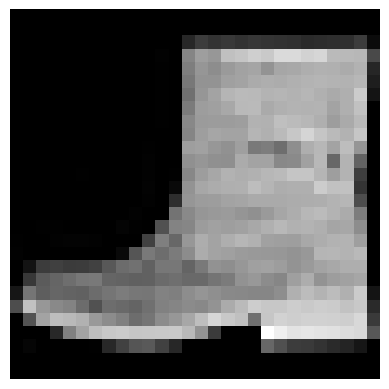

In [24]:
plt.imshow(X_sample.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [25]:
train_and_val_data.classes[y_sample]

'Ankle boot'

In [26]:
torch.flatten(torch.tensor([[[1, 2], [3, 4]]]))

tensor([1, 2, 3, 4])

In [27]:
class ImageClassifier(nn.Module):
  def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Flatten(),
        nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
        nn.Linear(n_hidden1, n_hidden2), nn.ReLU(),
        nn.Linear(n_hidden2, n_classes)
    )

  def forward(self, X):
    return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=28*28, n_hidden1=300, n_hidden2=100, n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

In [28]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
_ = train2(model, optimizer, accuracy, xentropy, train_loader, val_loader, n_epochs)

Epoch 1/20, train loss: 0.6060, train metric: 0.7816, val metric: 0.8418
Epoch 2/20, train loss: 0.4055, train metric: 0.8497, val metric: 0.8410
Epoch 3/20, train loss: 0.3630, train metric: 0.8659, val metric: 0.8500
Epoch 4/20, train loss: 0.3356, train metric: 0.8757, val metric: 0.8650
Epoch 5/20, train loss: 0.3149, train metric: 0.8841, val metric: 0.8794
Epoch 6/20, train loss: 0.2995, train metric: 0.8879, val metric: 0.8662
Epoch 7/20, train loss: 0.2856, train metric: 0.8922, val metric: 0.8766
Epoch 8/20, train loss: 0.2748, train metric: 0.8961, val metric: 0.8752
Epoch 9/20, train loss: 0.2639, train metric: 0.9005, val metric: 0.8826
Epoch 10/20, train loss: 0.2526, train metric: 0.9045, val metric: 0.8814
Epoch 11/20, train loss: 0.2462, train metric: 0.9075, val metric: 0.8842
Epoch 12/20, train loss: 0.2348, train metric: 0.9111, val metric: 0.8900
Epoch 13/20, train loss: 0.2290, train metric: 0.9123, val metric: 0.8850
Epoch 14/20, train loss: 0.2216, train metric: 

In [29]:
# make predictions from the first 3 samples in val data
model.eval()
X_new, y_new = next(iter(val_loader)) # get the first batch from val_loader
X_new = X_new[:3].to(device)
with torch.no_grad():
  y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)
y_pred

tensor([7, 4, 2])

In [30]:
[train_and_val_data.classes[idx] for idx in y_pred]

['Sneaker', 'Coat', 'Pullover']

In [31]:
y_new[:3]

tensor([7, 4, 2])

In [32]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0080, 0.0000, 0.8110, 0.0000,
         0.1810],
        [0.0000, 0.0000, 0.0090, 0.0000, 0.9900, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0010, 0.0020, 0.7500, 0.0010, 0.0850, 0.0000, 0.1580, 0.0000, 0.0030,
         0.0000]])

---

If you wish to apply label smoothing during training, just set the
`label_smoothing` hyperparameter of the `nn.CrossEntropyLoss` to
the amount of smoothing you wish, between 0 and 1 (e.g., 0.05).

https://chatgpt.com/share/6abdc71a-a9c0-83ec-bba1-27d4f782b512

---

In [33]:
# Looking at top 4 predictions
y_top4_logits, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_logits, dim=1)
y_top4_probas.round(decimals=3)

tensor([[0.8110, 0.1810, 0.0080, 0.0000],
        [0.9900, 0.0090, 0.0000, 0.0000],
        [0.7530, 0.1580, 0.0850, 0.0030]])

In [34]:
y_top4_indices

tensor([[7, 9, 5, 8],
        [4, 2, 6, 3],
        [2, 6, 4, 8]])

---

The Fashion MNIST dataset is balanced, meaning it has the same
number of instances of each class. When dealing with an unbal
anced dataset, you should generally give more weight to the rare
classes and less weight to the frequent ones, or else your model
will be biased toward the more frequent classes. You can do this
by setting the `weight` argument of the `nn.CrossEntropyLoss`.

For example, if there are three classes with 900, 700, and 400 instan
ces, respectively (i.e., 2000 instances in total), then the respective
weights should be 2000/900, 2000/700, and 2000/400. It’s preferable
to normalize these weights to ensure they add up to 1, so in this
example you would set `weight=torch.tensor([0.2205, 0.2835,
0.4961])`.

---

# Fine-Tuning Neural Network Hyperparameters with Optuna

In [35]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.2 MB/s eta 0:00:00


---

Optuna is an open-source, automatic hyperparameter optimization framework.

https://chatgpt.com/share/6abdcb4c-8890-83ec-9400-bcc74d436aa4

---

In [36]:
import optuna

def objective(trial):
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True) # ask Optuna for a good hyperparameter value in a given range
  n_hidden = trial.suggest_int('n_hidden', 20, 300)
  model = ImageClassifier(n_inputs=28*28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
  history = train2(model, optimizer, accuracy, xentropy, train_loader, val_loader, n_epochs=10)
  validation_accuracy = max(history['val_metrics'])
  return validation_accuracy

In [37]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-10-01 09:39:03,053] A new study created in memory with name: no-name-dc8ceaa1-b481-43b1-8ec7-df13e27190c7


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, val metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, val metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4109, val metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, val metric: 0.5560
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, val metric: 0.6026
Epoch 6/10, train loss: 1.5775, train metric: 0.6184, val metric: 0.6228
Epoch 7/10, train loss: 1.3978, train metric: 0.6288, val metric: 0.6326
Epoch 8/10, train loss: 1.2605, train metric: 0.6360, val metric: 0.6370
Epoch 9/10, train loss: 1.1572, train metric: 0.6467, val metric: 0.6424


[I 2026-10-01 09:44:17,417] Trial 0 finished with value: 0.6435999870300293 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.6435999870300293.


Epoch 10/10, train loss: 1.0782, train metric: 0.6537, val metric: 0.6436
Epoch 1/10, train loss: 1.1459, train metric: 0.6229, val metric: 0.7338
Epoch 2/10, train loss: 0.6108, train metric: 0.7842, val metric: 0.7992
Epoch 3/10, train loss: 0.5203, train metric: 0.8171, val metric: 0.8094
Epoch 4/10, train loss: 0.4810, train metric: 0.8301, val metric: 0.8310
Epoch 5/10, train loss: 0.4558, train metric: 0.8404, val metric: 0.8356
Epoch 6/10, train loss: 0.4388, train metric: 0.8461, val metric: 0.8444
Epoch 7/10, train loss: 0.4239, train metric: 0.8514, val metric: 0.8412
Epoch 8/10, train loss: 0.4122, train metric: 0.8563, val metric: 0.8508
Epoch 9/10, train loss: 0.3997, train metric: 0.8599, val metric: 0.8528


[I 2026-10-01 09:48:47,814] Trial 1 finished with value: 0.8539999723434448 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.8539999723434448.


...

Epoch 10/10, train loss: 2.2414, train metric: 0.2299, val metric: 0.2334
Epoch 1/10, train loss: 2.3035, train metric: 0.1373, val metric: 0.1526
Epoch 2/10, train loss: 2.3005, train metric: 0.1569, val metric: 0.1724
Epoch 3/10, train loss: 2.2975, train metric: 0.1755, val metric: 0.1896
Epoch 4/10, train loss: 2.2945, train metric: 0.1941, val metric: 0.2132
Epoch 5/10, train loss: 2.2914, train metric: 0.2105, val metric: 0.2288
Epoch 6/10, train loss: 2.2884, train metric: 0.2261, val metric: 0.2418
Epoch 7/10, train loss: 2.2853, train metric: 0.2419, val metric: 0.2580
Epoch 8/10, train loss: 2.2823, train metric: 0.2581, val metric: 0.2742
Epoch 9/10, train loss: 2.2792, train metric: 0.2736, val metric: 0.2918


[I 2026-10-01 09:56:23,299] Trial 3 finished with value: 0.30959999561309814 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.8539999723434448.


Epoch 10/10, train loss: 2.2761, train metric: 0.2897, val metric: 0.3096
Epoch 1/10, train loss: 1.8379, train metric: 0.4869, val metric: 0.6208
Epoch 2/10, train loss: 0.9751, train metric: 0.6666, val metric: 0.6974
Epoch 3/10, train loss: 0.7608, train metric: 0.7253, val metric: 0.7416
Epoch 4/10, train loss: 0.6704, train metric: 0.7639, val metric: 0.7720
Epoch 5/10, train loss: 0.6108, train metric: 0.7913, val metric: 0.7906
Epoch 6/10, train loss: 0.5687, train metric: 0.8054, val metric: 0.8052
Epoch 7/10, train loss: 0.5386, train metric: 0.8164, val metric: 0.8082
Epoch 8/10, train loss: 0.5158, train metric: 0.8243, val metric: 0.8212
Epoch 9/10, train loss: 0.4988, train metric: 0.8281, val metric: 0.8220


[I 2026-10-01 09:59:39,230] Trial 4 finished with value: 0.8220000267028809 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.8539999723434448.


Epoch 10/10, train loss: 0.4842, train metric: 0.8330, val metric: 0.8092


In [38]:
study.best_params

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}

In [39]:
study.best_value

0.8539999723434448

---

You may have noticed that we assumed that the `objective()` function had direct
access to the training set and validation, presumably via global variables. In general, it’s much cleaner to pass them as extra arguments to the `objective()` function, for example, like this:

---

In [41]:
def objective(trial, train_loader, val_loader):
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True) # ask Optuna for a good hyperparameter value in a given range
  n_hidden = trial.suggest_int('n_hidden', 20, 300)
  model = ImageClassifier(n_inputs=28*28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
  history = train2(model, optimizer, accuracy, xentropy, train_loader, val_loader, n_epochs=10)
  validation_accuracy = max(history['val_metrics'])
  return validation_accuracy

objective_with_data = lambda trial: objective( # set the extra arguments (dataset loaders)
    trial, train_loader=train_loader, val_loader=val_loader
)

---

Alternatively, you can
use the `functools.partial()` function which creates a thin wrapper function around the given callable to provide default values for any number of arguments:

---

In [42]:
from functools import partial

objective_with_data = partial(objective, train_loader=train_loader, val_loader=val_loader)

---

Optuna comes with several Pruner classes that can detect and prune bad trials. For example, the `MedianPruner` (default of `optuna.create_study()`) will prune trials whose performance is below the median performance, at regular intervals during training. It starts pruning after a given number of trials have completed, controlled by `n_startup_trials` (5 by default). For each
trial after that, it lets training start for a few epochs, controlled by `n_warmup_steps` (0 by default); then every few epochs (controlled by `interval_steps`, 1 by default), it ensures that the model’s performance is better than the median performance at the same epoch in past trials.

---

In [43]:
def objective(trial, train_loader, val_loader):
  learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True) # ask Optuna for a good hyperparameter value in a given range
  n_hidden = trial.suggest_int('n_hidden', 20, 300)
  model = ImageClassifier(n_inputs=28*28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
  xentropy = nn.CrossEntropyLoss()
  accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

  best_val_accuracy = 0.0
  for epoch in range(n_epochs):
    history = train2(model, optimizer, accuracy, xentropy, train_loader, val_loader, n_epochs=1)
    validation_accuracy = max(history['val_metrics'])
    if validation_accuracy > best_val_accuracy:
      best_val_accuracy = validation_accuracy
    trial.report(validation_accuracy, epoch)
    if trial.should_prune():
      raise optuna.TrialPruned()
  return best_val_accuracy

In [44]:
objective_with_data = partial(objective, train_loader=train_loader, val_loader=val_loader)

In [45]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0,
                                      interval_steps=1)
study = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
study.optimize(objective_with_data, n_trials=10)

[I 2026-10-01 10:01:02,870] A new study created in memory with name: no-name-e62606c3-6b09-4f87-a0ec-fe456b4b84d7


Epoch 1/1, train loss: 2.3143, train metric: 0.0998, val metric: 0.1018
Epoch 1/1, train loss: 2.3116, train metric: 0.0998, val metric: 0.1018
Epoch 1/1, train loss: 2.3090, train metric: 0.0998, val metric: 0.1018
Epoch 1/1, train loss: 2.3063, train metric: 0.0998, val metric: 0.1018
Epoch 1/1, train loss: 2.3037, train metric: 0.0998, val metric: 0.1018
Epoch 1/1, train loss: 2.3011, train metric: 0.0998, val metric: 0.1018
Epoch 1/1, train loss: 2.2986, train metric: 0.0999, val metric: 0.1024
Epoch 1/1, train loss: 2.2960, train metric: 0.1006, val metric: 0.1034
Epoch 1/1, train loss: 2.2935, train metric: 0.1035, val metric: 0.1086
Epoch 1/1, train loss: 2.2909, train metric: 0.1124, val metric: 0.1238
Epoch 1/1, train loss: 2.2884, train metric: 0.1307, val metric: 0.1510
Epoch 1/1, train loss: 2.2859, train metric: 0.1594, val metric: 0.1826
Epoch 1/1, train loss: 2.2834, train metric: 0.1950, val metric: 0.2236
Epoch 1/1, train loss: 2.2809, train metric: 0.2310, val metric:

[I 2026-10-01 10:09:58,350] Trial 0 finished with value: 0.3594000041484833 and parameters: {'learning_rate': 1.2087541473056957e-05, 'n_hidden': 292}. Best is trial 0 with value: 0.3594000041484833.


Epoch 1/1, train loss: 2.2659, train metric: 0.3518, val metric: 0.3594
Epoch 1/1, train loss: 0.8644, train metric: 0.6997, val metric: 0.7778
Epoch 1/1, train loss: 0.5037, train metric: 0.8227, val metric: 0.8300
Epoch 1/1, train loss: 0.4503, train metric: 0.8403, val metric: 0.8416
Epoch 1/1, train loss: 0.4168, train metric: 0.8516, val metric: 0.8478
Epoch 1/1, train loss: 0.3946, train metric: 0.8584, val metric: 0.8516
Epoch 1/1, train loss: 0.3749, train metric: 0.8636, val metric: 0.8602
Epoch 1/1, train loss: 0.3603, train metric: 0.8676, val metric: 0.8614
Epoch 1/1, train loss: 0.3484, train metric: 0.8731, val metric: 0.8522
Epoch 1/1, train loss: 0.3376, train metric: 0.8767, val metric: 0.8634
Epoch 1/1, train loss: 0.3286, train metric: 0.8799, val metric: 0.8612
Epoch 1/1, train loss: 0.3201, train metric: 0.8840, val metric: 0.8708
Epoch 1/1, train loss: 0.3127, train metric: 0.8858, val metric: 0.8696
Epoch 1/1, train loss: 0.3050, train metric: 0.8877, val metric:

[I 2026-10-01 10:15:37,261] Trial 1 finished with value: 0.8845999836921692 and parameters: {'learning_rate': 0.021368329072358756, 'n_hidden': 79}. Best is trial 1 with value: 0.8845999836921692.


...

Epoch 1/1, train loss: 0.5790, train metric: 0.8017, val metric: 0.7884


[I 2026-10-01 10:47:58,125] Trial 8 pruned. 


Epoch 1/1, train loss: 2.2965, train metric: 0.1297, val metric: 0.1630
Epoch 1/1, train loss: 2.0187, train metric: 0.3253, val metric: 0.4886
Epoch 1/1, train loss: 1.1611, train metric: 0.6360, val metric: 0.6752
Epoch 1/1, train loss: 0.8461, train metric: 0.7093, val metric: 0.7162
Epoch 1/1, train loss: 0.7263, train metric: 0.7433, val metric: 0.7478
Epoch 1/1, train loss: 0.6641, train metric: 0.7623, val metric: 0.7514
Epoch 1/1, train loss: 0.6233, train metric: 0.7774, val metric: 0.7768
Epoch 1/1, train loss: 0.5939, train metric: 0.7885, val metric: 0.7852
Epoch 1/1, train loss: 0.5706, train metric: 0.7976, val metric: 0.7942
Epoch 1/1, train loss: 0.5509, train metric: 0.8072, val metric: 0.8068
Epoch 1/1, train loss: 0.5343, train metric: 0.8133, val metric: 0.8084
Epoch 1/1, train loss: 0.5196, train metric: 0.8182, val metric: 0.8146
Epoch 1/1, train loss: 0.5064, train metric: 0.8235, val metric: 0.8154
Epoch 1/1, train loss: 0.4961, train metric: 0.8276, val metric:

[I 2026-10-01 10:53:57,828] Trial 9 finished with value: 0.8361999988555908 and parameters: {'learning_rate': 0.00234238498471129, 'n_hidden': 33}. Best is trial 1 with value: 0.8845999836921692.


Epoch 1/1, train loss: 0.4493, train metric: 0.8436, val metric: 0.8344


# Saving and Loading PyTorch Models

---

Good reference: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html


The simplest way to save a PyTorch model is to use the `torch.save()` method,
passing it the model and the filepath. The model object is serialized using Python’s `pickle` module (which can convert objects into a sequence of bytes), then the result is compressed (zip) and saved to disk. The convention is to use the `.pt` or `.pth` extension for PyTorch files.

---

In [46]:
torch.save(model, 'my_fashion_mnist.pt') #

In [47]:
loaded_model = torch.load('my_fashion_mnist.pt', weights_only=False) # weights_only=False: whole model object is loaded rather than just the model parameters

---

If your model uses any custom functions or classes (e.g., `ImageClas
sifier`), then `torch.save()` only saves references to them, not the
code itself. Therefore you must ensure that any custom code is
loaded in the Python environment before calling `torch.load()`.
Also make sure to use the same version of the code to avoid any
mismatch issues.

---

---

This is nice and easy, but unfortunately this approach has some very serious
drawbacks: insecure, brittle, varying depending on Python version...

To avoid these issues, it is recommended to save and load the model weights only, rather than the full model object:

---

In [48]:
torch.save(model.state_dict(), 'my_fashion_mnist_weights.pt')

In [49]:
type(model.state_dict())

collections.OrderedDict

In [50]:
new_model = ImageClassifier(n_inputs=28*28, n_hidden1=300, n_hidden2=100,
                            n_classes=10)
loaded_weights = torch.load('my_fashion_mnist_weights.pt', weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

---

This is safer, but you still need to recreate the exact architecture of the model before loaded the state dict. Therefore, it's a good idea to save this information along with the state dict in a dictionary.

---

In [51]:
model_data = {
    'model_state_dict': model.state_dict(),
    'model_hyperparameters': {
        'n_inputs': 1*28*28,
        'n_hidden1': 300,
        'n_hidden2': 100,
        'n_classes': 10,
    }
}
torch.save(model_data, 'my_fashion_mnist_model.pt')

In [52]:
loaded_data = torch.load('my_fashion_mnist_model.pt', weights_only=True)
new_model = ImageClassifier(**loaded_data['model_hyperparameters'])
new_model.load_state_dict(loaded_data['model_state_dict'])
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

---

The `safetensors` library by Hugging Face is another popular way to save model weights safely.

https://chatgpt.com/share/6abe3a12-be64-83ec-a9e5-fe975e84fcce

---

# Compiling and Optimizing a PyTorch Model

---

One way is to convert your model's code into TorchScript.

https://chatgpt.com/share/6abe4310-0df4-83ec-bf01-3e69273c6e32

---

In [53]:
torchscript_model = torch.jit.trace(model, X_new)

In [54]:
torchscript_model

ImageClassifier(
  original_name=ImageClassifier
  (mlp): Sequential(
    original_name=Sequential
    (0): Flatten(original_name=Flatten)
    (1): Linear(original_name=Linear)
    (2): ReLU(original_name=ReLU)
    (3): Linear(original_name=Linear)
    (4): ReLU(original_name=ReLU)
    (5): Linear(original_name=Linear)
  )
)

In [55]:
torchscript_model = torch.jit.script(model)

In [56]:
torchscript_model

RecursiveScriptModule(
  original_name=ImageClassifier
  (mlp): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Flatten)
    (1): RecursiveScriptModule(original_name=Linear)
    (2): RecursiveScriptModule(original_name=ReLU)
    (3): RecursiveScriptModule(original_name=Linear)
    (4): RecursiveScriptModule(original_name=ReLU)
    (5): RecursiveScriptModule(original_name=Linear)
  )
)

We can further optimize this using `optimize_for_inference`. It takes a TorchScript model and applies inference-specific optimizations to make it potentially faster and/or lighter during inference.

In [57]:
optimized_model = torch.jit.optimize_for_inference(torchscript_model)

---

TorchScript models can only be used for inference, not for training, since the TorchScript environment doesn’t support gradient tracking or parameter updates.

---

In [59]:
# save the model
torchscript_model.save('my_fashion_mnist_torchscript.pt')

In [60]:
# load the model
loaded_torchscript_model = torch.jit.load('my_fashion_mnist_torchscript.pt')

In [61]:
loaded_torchscript_model

RecursiveScriptModule(
  original_name=ImageClassifier
  (mlp): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Flatten)
    (1): RecursiveScriptModule(original_name=Linear)
    (2): RecursiveScriptModule(original_name=ReLU)
    (3): RecursiveScriptModule(original_name=Linear)
    (4): RecursiveScriptModule(original_name=ReLU)
    (5): RecursiveScriptModule(original_name=Linear)
  )
)

---

Another more modern way to compile model is using `torch.compile()`.

---

In [62]:
compiled_model = torch.compile(model)

In [63]:
compiled_model

OptimizedModule(
  (_orig_mod): ImageClassifier(
    (mlp): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=300, bias=True)
      (2): ReLU()
      (3): Linear(in_features=300, out_features=100, bias=True)
      (4): ReLU()
      (5): Linear(in_features=100, out_features=10, bias=True)
    )
  )
)